In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
df = pd.read_csv('../../../Data/Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
df.shape

(400, 3)

In [4]:
df = df[['Age','EstimatedSalary','Purchased']]

In [5]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [18]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
X_scaled.shape

(400, 2)

In [8]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Input

In [9]:
model = Sequential()

model.add(Input(shape=(2,)))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

### Batch_size = n --> Batch Gradient Descent
### Batch_size = 1 --> Stochastics Gradient Descent

In [20]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=200,batch_size=1,validation_split=0.2)
print(time.time() - start)

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9094 - loss: 0.2186 - val_accuracy: 0.9500 - val_loss: 0.2357
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.9094 - loss: 0.2257 - val_accuracy: 0.9500 - val_loss: 0.2172
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.9125 - loss: 0.2467 - val_accuracy: 0.9375 - val_loss: 0.2537
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.9094 - loss: 0.2488 - val_accuracy: 0.9500 - val_loss: 0.2087
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.9125 - loss: 0.2583 - val_accuracy: 0.9375 - val_loss: 0.2396
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.9094 - loss: 0.2621 - val_accuracy: 0.9500 - val_loss: 0.2186
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.9094 - loss: 0.2588 - val_accuracy: 0.9375 - val_loss: 0.2203
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.9094 - loss: 0.2

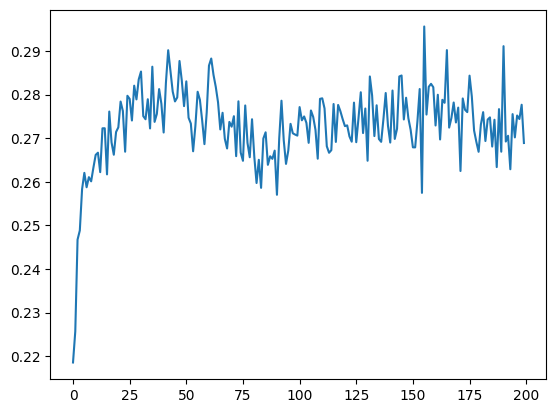

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [22]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9125 - loss: 0.2708 - val_accuracy: 0.9375 - val_loss: 0.2344
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9156 - loss: 0.2595 - val_accuracy: 0.9375 - val_loss: 0.2548
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9156 - loss: 0.2531 - val_accuracy: 0.9375 - val_loss: 0.2546
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9156 - loss: 0.2482 - val_accuracy: 0.9375 - val_loss: 0.2540
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9156 - loss: 0.2435 - val_accuracy: 0.9250 - val_loss: 0.2732
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9156 - loss: 0.2398 - val_accuracy: 0.9250 - val_loss: 0.2715
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9156 - loss: 0.2385 - val_accuracy: 0.9250 - val_loss: 0.2672
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9156 - loss: 0.2371 - val_accuracy: 0.9250 - val_loss: 0.2830

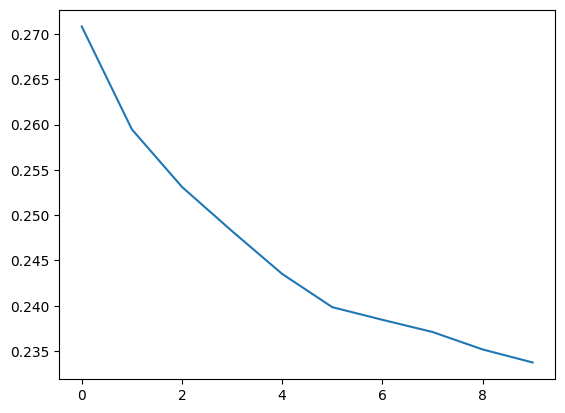

In [23]:
plt.plot(history.history['loss'])